# 64 — Construction-Only Feature Domain Fingerprinting

**Project:** AI VPN Firewall — Thesis
**Source pipeline:** Clean Pipeline (NB41-55)
**Goal:** Test whether flow construction statistics alone encode dataset identity.

---

## Rationale

The five lowest-level flow construction features — flow_duration, total_packets,
total_bytes, packet_rate, byte_rate — are computed directly from raw packet
timestamps and sizes **before** any statistical aggregation.

If a domain classifier trained on *only* these five features achieves high AUC,
it demonstrates that the construction pipeline itself encodes dataset identity,
meaning domain shift is present in the fundamental flow statistics, not just in
higher-order engineered features.

We use **capture-safe StratifiedGroupKFold** (groups = capture_id, stratified by
dataset) so no flows from the same capture session appear in both train and test
folds, and every fold's test set contains captures from all three datasets.

| Step | Detail |
|---|---|
| Features | flow_duration, total_packets, total_bytes, packet_rate, byte_rate |
| Target | dataset_id (multi-class) |
| CV | StratifiedGroupKFold(n_splits=5, groups=capture_id, strat=dataset) |
| Metric | OvR macro AUC |
| Comparison | Full-feature (21) domain AUC |

## 0. Setup

In [1]:
import sys, warnings, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
OUT = ROOT / "artifacts" / "thesis_finalization" / "nb64_construction_only_domain_fingerprinting"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

SEED = 42
N_SPLITS = 5
N_EST = 200
print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## 1. Load Data & Define Feature Sets

In [2]:
from src.clean_pipeline.feature_families import get_family

FULL_FEATURES = list(get_family("safe_core_plus_temporal"))

CONSTRUCTION_FEATURES = [
    "flow_duration",
    "total_packets",
    "total_bytes",
    "packet_rate",
    "byte_rate",
]

df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())

# Verify all features present
missing_c = [f for f in CONSTRUCTION_FEATURES if f not in df_all.columns]
missing_f = [f for f in FULL_FEATURES if f not in df_all.columns]
assert not missing_c, f"Missing construction features: {missing_c}"
assert not missing_f, f"Missing full features: {missing_f}"

print(f"Datasets:              {DATASETS}")
print(f"Total flows:           {len(df_all):,}")
print(f"Construction features: {len(CONSTRUCTION_FEATURES)}  {CONSTRUCTION_FEATURES}")
print(f"Full features:         {len(FULL_FEATURES)}")
print(f"Unique captures:       {df_all['capture_id'].nunique()}")

# Per-dataset summary
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    n_cap = sub["capture_id"].nunique()
    print(f"  {ds:8s}: {len(sub):>6,} flows, {n_cap:>3} captures")

Datasets:              ['iscx', 'usbvpn', 'vnat']
Total flows:           72,612
Construction features: 5  ['flow_duration', 'total_packets', 'total_bytes', 'packet_rate', 'byte_rate']
Full features:         21
Unique captures:       340
  iscx    : 11,801 flows, 140 captures
  usbvpn  : 52,704 flows,  35 captures
  vnat    :  8,107 flows, 165 captures


---
## 2. Stratified-Group Splitter & Domain Classifier

Build folds at the capture level, stratified by dataset, so every fold's test
set contains captures from all three datasets. No capture_id may appear in both
train and test within a fold.

In [3]:
def stratified_group_kfold(df, n_splits=5, seed=42):
    """
    Capture-level stratified splitting.

    Algorithm:
      1. Build a table of unique (capture_id → dataset) pairs.
      2. Within each dataset, shuffle the captures deterministically.
      3. Assign captures round-robin to folds (0, 1, ..., n_splits-1).
      4. Map capture-level fold assignment back to the flow level.

    Guarantees:
      - Capture exclusivity: no capture_id in both train and test.
      - Class coverage: every fold's test set has ≥1 capture from every dataset
        (requires n_captures_per_dataset ≥ n_splits).
    """
    rng = np.random.RandomState(seed)

    # Unique capture → dataset mapping
    cap_ds = df.groupby("capture_id")["dataset"].first().reset_index()
    cap_ds.columns = ["capture_id", "dataset"]

    # Assign each capture to a fold, stratified by dataset
    cap_ds["fold"] = -1
    for ds in sorted(cap_ds["dataset"].unique()):
        mask = cap_ds["dataset"] == ds
        idxs = cap_ds.index[mask].values.copy()
        rng.shuffle(idxs)
        for i, idx in enumerate(idxs):
            cap_ds.loc[idx, "fold"] = i % n_splits

    # Map capture → fold back to flow level
    cap_fold = dict(zip(cap_ds["capture_id"], cap_ds["fold"]))
    flow_folds = df["capture_id"].map(cap_fold).values

    splits = []
    for fold_i in range(n_splits):
        test_mask = flow_folds == fold_i
        train_mask = ~test_mask
        splits.append((np.where(train_mask)[0], np.where(test_mask)[0]))

    return splits, cap_ds


def capture_safe_domain_auc(df, feat_cols, n_splits=5, n_est=200, seed=42, verbose=True):
    """
    Capture-safe domain classification via stratified-group K-fold.
    Returns per-fold results and overall macro AUC.
    All folds are guaranteed to have all dataset classes in both train and test.
    """
    le = LabelEncoder()
    X = df[feat_cols].values
    y = le.fit_transform(df["dataset"].values)
    groups = df["capture_id"].values
    n_classes = len(le.classes_)

    splits, cap_ds = stratified_group_kfold(df, n_splits=n_splits, seed=seed)
    fold_results = []

    for fold_i, (tr_idx, te_idx) in enumerate(splits):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # Verify all classes present
        train_classes = set(np.unique(y_tr))
        test_classes = set(np.unique(y_te))
        all_present_train = train_classes == set(range(n_classes))
        all_present_test = test_classes == set(range(n_classes))

        clf = xgb.XGBClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="mlogloss", random_state=seed,
            n_jobs=-1, verbosity=0,
        )
        clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
        prob = clf.predict_proba(X_te)
        y_pred = clf.predict(X_te)

        if n_classes == 2:
            auc = float(roc_auc_score(y_te, prob[:, 1]))
        else:
            auc = float(roc_auc_score(y_te, prob, multi_class="ovr", average="macro"))

        acc = float(accuracy_score(y_te, y_pred))
        n_train_caps = len(np.unique(groups[tr_idx]))
        n_test_caps = len(np.unique(groups[te_idx]))

        # Per-dataset breakdown for this fold
        ds_test = df.iloc[te_idx]["dataset"].values
        ds_train = df.iloc[tr_idx]["dataset"].values
        test_ds_flows = dict(Counter(ds_test))
        train_ds_flows = dict(Counter(ds_train))

        fold_results.append({
            "fold": fold_i, "auc": auc, "accuracy": acc,
            "n_train": len(tr_idx), "n_test": len(te_idx),
            "n_train_captures": n_train_caps, "n_test_captures": n_test_caps,
            "all_classes_train": all_present_train,
            "all_classes_test": all_present_test,
            "test_flows_per_dataset": test_ds_flows,
            "train_flows_per_dataset": train_ds_flows,
        })
        if verbose:
            print(f"  Fold {fold_i}: AUC={auc:.4f}, Acc={acc:.4f}  "
                  f"(train={len(tr_idx):,}, test={len(te_idx):,}, "
                  f"caps_train={n_train_caps}, caps_test={n_test_caps})  "
                  f"all_classes_test={all_present_test}")

    aucs = [f["auc"] for f in fold_results]
    mean_auc = float(np.mean(aucs))
    std_auc = float(np.std(aucs))

    return {
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "folds": fold_results,
        "classes": list(le.classes_),
        "n_splits": n_splits,
    }

print("\u2713 stratified_group_kfold() and capture_safe_domain_auc() defined.")

✓ stratified_group_kfold() and capture_safe_domain_auc() defined.


---
## 2b. Fold Diagnostics

Show capture and flow distribution per dataset per fold.

In [4]:
_, cap_ds_info = stratified_group_kfold(df_all, n_splits=N_SPLITS, seed=SEED)

print("Captures per dataset per fold:")
print("=" * 60)
pivot_caps = cap_ds_info.groupby(["fold", "dataset"]).size().unstack(fill_value=0)
display(pivot_caps)

print("\nFlows per dataset per fold:")
print("=" * 60)
df_all_with_fold = df_all.copy()
cap_fold_map = dict(zip(cap_ds_info["capture_id"], cap_ds_info["fold"]))
df_all_with_fold["fold"] = df_all_with_fold["capture_id"].map(cap_fold_map)
pivot_flows = df_all_with_fold.groupby(["fold", "dataset"]).size().unstack(fill_value=0)
display(pivot_flows)

# Verify: all folds have all datasets
for fold_i in range(N_SPLITS):
    ds_in_fold = set(cap_ds_info.loc[cap_ds_info["fold"] == fold_i, "dataset"])
    assert ds_in_fold == set(DATASETS), f"Fold {fold_i} missing datasets: {set(DATASETS) - ds_in_fold}"
print(f"\n\u2713 All {N_SPLITS} folds contain captures from all {len(DATASETS)} datasets.")

# Verify: no capture leakage
for fold_i in range(N_SPLITS):
    test_caps = set(cap_ds_info.loc[cap_ds_info["fold"] == fold_i, "capture_id"])
    train_caps = set(cap_ds_info.loc[cap_ds_info["fold"] != fold_i, "capture_id"])
    assert test_caps.isdisjoint(train_caps), f"Fold {fold_i}: capture leakage!"
print("\u2713 No capture leakage across folds.")

Captures per dataset per fold:

dataset,iscx,usbvpn,vnat
fold,,,
0,28,7,33
1,28,7,33
2,28,7,33
3,28,7,33
4,28,7,33



Flows per dataset per fold:


dataset,iscx,usbvpn,vnat
fold,,,
0,1944,1831,2129
1,1589,5282,499
2,2568,1738,1889
3,2842,41371,2393
4,2858,2482,1197



✓ All 5 folds contain captures from all 3 datasets.
✓ No capture leakage across folds.


In [5]:
print("=" * 60)
print("CONSTRUCTION-ONLY features (5)")
print("=" * 60)
result_construction = capture_safe_domain_auc(
    df_all, CONSTRUCTION_FEATURES, n_splits=N_SPLITS, n_est=N_EST, seed=SEED
)
print(f"\nMean AUC: {result_construction['mean_auc']:.4f} "
      f"\u00b1 {result_construction['std_auc']:.4f}")

print()
print("=" * 60)
print("FULL features (21)")
print("=" * 60)
result_full = capture_safe_domain_auc(
    df_all, FULL_FEATURES, n_splits=N_SPLITS, n_est=N_EST, seed=SEED
)
print(f"\nMean AUC: {result_full['mean_auc']:.4f} "
      f"\u00b1 {result_full['std_auc']:.4f}")

CONSTRUCTION-ONLY features (5)


  Fold 0: AUC=0.9251, Acc=0.7598  (train=66,708, test=5,904, caps_train=272, caps_test=68)  all_classes_test=True


  Fold 1: AUC=0.9651, Acc=0.8982  (train=65,242, test=7,370, caps_train=272, caps_test=68)  all_classes_test=True


  Fold 2: AUC=0.9669, Acc=0.8437  (train=66,417, test=6,195, caps_train=272, caps_test=68)  all_classes_test=True


  Fold 3: AUC=0.9619, Acc=0.7820  (train=26,006, test=46,606, caps_train=272, caps_test=68)  all_classes_test=True


...

  Fold 1: AUC=0.9995, Acc=0.9852  (train=65,242, test=7,370, caps_train=272, caps_test=68)  all_classes_test=True


  Fold 2: AUC=0.9998, Acc=0.9926  (train=66,417, test=6,195, caps_train=272, caps_test=68)  all_classes_test=True


  Fold 3: AUC=0.9979, Acc=0.9626  (train=26,006, test=46,606, caps_train=272, caps_test=68)  all_classes_test=True


  Fold 4: AUC=0.9998, Acc=0.9872  (train=66,075, test=6,537, caps_train=272, caps_test=68)  all_classes_test=True



Mean AUC: 0.9987 ± 0.0014


---
## 3. Per-Feature Solo Domain AUC

Rank each construction feature individually.

In [6]:
solo_rows = []
for feat in CONSTRUCTION_FEATURES:
    print(f"  {feat}...")
    r = capture_safe_domain_auc(df_all, [feat], n_splits=N_SPLITS, n_est=100, seed=SEED, verbose=False)
    solo_rows.append({"feature": feat, "domain_auc": r["mean_auc"], "std": r["std_auc"]})

solo_df = pd.DataFrame(solo_rows).sort_values("domain_auc", ascending=False).reset_index(drop=True)
print()
display(solo_df.round(4).style.set_caption("Per-Feature Solo Domain AUC (Construction Features)"))

  flow_duration...


  total_packets...


  total_bytes...


  packet_rate...


  byte_rate...


,feature,domain_auc,std
0,total_bytes,0.846400,0.061300
1,byte_rate,0.841100,0.024800
2,flow_duration,0.829000,0.050800
3,packet_rate,0.827300,0.030200
4,total_packets,0.799500,0.059000


---
## 4. Comparison Table

In [7]:
comparison_rows = [
    {
        "feature_set": "construction_only",
        "n_features": len(CONSTRUCTION_FEATURES),
        "features": ", ".join(CONSTRUCTION_FEATURES),
        "capture_safe_domain_auc": result_construction["mean_auc"],
        "std_auc": result_construction["std_auc"],
    },
    {
        "feature_set": "full_21",
        "n_features": len(FULL_FEATURES),
        "features": "(all safe_core_plus_temporal)",
        "capture_safe_domain_auc": result_full["mean_auc"],
        "std_auc": result_full["std_auc"],
    },
]
comp_df = pd.DataFrame(comparison_rows)

ratio = result_construction["mean_auc"] / max(result_full["mean_auc"], 1e-9)
delta = result_construction["mean_auc"] - result_full["mean_auc"]

print("\n" + "=" * 60)
print("COMPARISON: Construction-Only vs Full Feature Domain AUC")
print("=" * 60)
print(f"  Construction-only AUC: {result_construction['mean_auc']:.4f}")
print(f"  Full-feature AUC:      {result_full['mean_auc']:.4f}")
print(f"  Ratio:                 {ratio:.4f}")
print(f"  Delta:                 {delta:+.4f}")
print()

if result_construction["mean_auc"] > 0.90:
    interpretation = (
        "STRONG: Construction features alone achieve near-perfect domain classification. "
        "The flow construction pipeline encodes dataset identity at the most fundamental level."
    )
elif result_construction["mean_auc"] > 0.75:
    interpretation = (
        "MODERATE: Construction features encode substantial dataset identity. "
        "Domain shift is partially embedded in basic flow statistics."
    )
else:
    interpretation = (
        "WEAK: Construction features alone do not strongly encode dataset identity. "
        "Domain shift may be driven by higher-order statistical features."
    )

print(f"  Interpretation: {interpretation}")

# Verify no NaN folds
nan_folds_c = sum(1 for f in result_construction["folds"] if np.isnan(f["auc"]))
nan_folds_f = sum(1 for f in result_full["folds"] if np.isnan(f["auc"]))
print(f"\n  NaN folds (construction): {nan_folds_c}")
print(f"  NaN folds (full):         {nan_folds_f}")
assert nan_folds_c == 0, "Construction folds have NaN AUC!"
assert nan_folds_f == 0, "Full folds have NaN AUC!"
print("  \u2713 All folds produced valid AUC values.")

display(comp_df.round(4).style.set_caption("Construction-Only vs Full Domain AUC"))


COMPARISON: Construction-Only vs Full Feature Domain AUC
  Construction-only AUC: 0.9600
  Full-feature AUC:      0.9987
  Ratio:                 0.9612
  Delta:                 -0.0387

  Interpretation: STRONG: Construction features alone achieve near-perfect domain classification. The flow construction pipeline encodes dataset identity at the most fundamental level.

  NaN folds (construction): 0
  NaN folds (full):         0
  ✓ All folds produced valid AUC values.


,feature_set,n_features,features,capture_safe_domain_auc,std_auc
0,construction_only,5,"flow_duration, total_packets, total_bytes, packet_rate, byte_rate",0.960000,0.018600
1,full_21,21,(all safe_core_plus_temporal),0.998700,0.001400


---
## 5. Visualization

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# -- Panel A: Bar comparison --
ax = axes[0]
labels = ["Construction\n(5 features)", "Full\n(21 features)"]
aucs = [result_construction["mean_auc"], result_full["mean_auc"]]
stds = [result_construction["std_auc"], result_full["std_auc"]]
colors = ["#FF9800", "#2196F3"]
bars = ax.bar(range(2), aucs, yerr=stds, capsize=8, color=colors,
              edgecolor="black", linewidth=0.8, alpha=0.85, width=0.55)
for i, (m, s) in enumerate(zip(aucs, stds)):
    ax.text(i, m + s + 0.02, f"{m:.3f}", ha="center", va="bottom",
            fontweight="bold", fontsize=13)
ax.set_xticks(range(2))
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Capture-Safe Domain AUC", fontsize=12)
ax.set_title("Construction-Only vs Full Feature\nDomain Classification", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# -- Panel B: Per-fold comparison --
ax = axes[1]
folds_c = [f["auc"] for f in result_construction["folds"]]
folds_f = [f["auc"] for f in result_full["folds"]]
x = np.arange(len(folds_c))
w = 0.35
ax.bar(x - w/2, folds_c, w, color="#FF9800", edgecolor="black", linewidth=0.6, alpha=0.85, label="Construction (5)")
ax.bar(x + w/2, folds_f, w, color="#2196F3", edgecolor="black", linewidth=0.6, alpha=0.85, label="Full (21)")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(len(folds_c))], fontsize=10)
ax.set_ylabel("Domain AUC", fontsize=12)
ax.set_title("Per-Fold Domain AUC", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# -- Panel C: Solo feature AUC --
ax = axes[2]
feat_labels = solo_df["feature"].values
feat_aucs = solo_df["domain_auc"].values
feat_stds = solo_df["std"].values
bar_colors = plt.cm.Oranges(np.linspace(0.4, 0.85, len(feat_labels)))
bars = ax.barh(range(len(feat_labels)), feat_aucs, xerr=feat_stds, capsize=4,
               color=bar_colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax.set_yticks(range(len(feat_labels)))
ax.set_yticklabels(feat_labels, fontsize=10)
ax.set_xlabel("Solo Domain AUC", fontsize=12)
ax.set_title("Per-Feature Domain AUC\n(Construction Features)", fontsize=13, fontweight="bold")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax.set_xlim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

plt.suptitle("NB64: Construction-Only Feature Domain Fingerprinting\n(Stratified-Group CV \u2014 All Folds Valid)",
             fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "construction_only_domain_auc_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: construction_only_domain_auc_plot.png")

[OK] Saved: construction_only_domain_auc_plot.png


---
## 6. Export

In [9]:
# -- CSV --
export_rows = []
for label, res, feats in [
    ("construction_only", result_construction, CONSTRUCTION_FEATURES),
    ("full_21", result_full, FULL_FEATURES),
]:
    for fold in res["folds"]:
        export_rows.append({
            "feature_set": label,
            "n_features": len(feats),
            "fold": fold["fold"],
            "domain_auc": fold["auc"],
            "accuracy": fold["accuracy"],
            "n_train": fold["n_train"],
            "n_test": fold["n_test"],
            "n_train_captures": fold["n_train_captures"],
            "n_test_captures": fold["n_test_captures"],
            "all_classes_test": fold["all_classes_test"],
        })
export_df = pd.DataFrame(export_rows)
export_df.to_csv(OUT / "construction_only_domain_auc.csv", index=False)
print(f"[OK] Saved: construction_only_domain_auc.csv ({len(export_df)} rows)")

# -- Solo feature CSV --
solo_df.to_csv(OUT / "construction_solo_feature_domain_auc.csv", index=False)
print(f"[OK] Saved: construction_solo_feature_domain_auc.csv")

# -- JSON summary --
summary = {
    "notebook": "NB64",
    "title": "Construction-Only Feature Domain Fingerprinting",
    "correction_note": (
        "Replaced plain GroupKFold with stratified-group K-fold. "
        "Captures are assigned to folds round-robin within each dataset, "
        "guaranteeing all dataset classes in every fold's train and test sets. "
        "No NaN AUC folds. All 5 folds contribute to the mean."
    ),
    "datasets": DATASETS,
    "construction_features": CONSTRUCTION_FEATURES,
    "n_construction": len(CONSTRUCTION_FEATURES),
    "n_full": len(FULL_FEATURES),
    "construction_domain_auc": result_construction["mean_auc"],
    "construction_domain_auc_std": result_construction["std_auc"],
    "full_domain_auc": result_full["mean_auc"],
    "full_domain_auc_std": result_full["std_auc"],
    "ratio": float(ratio),
    "delta": float(delta),
    "interpretation": interpretation,
    "nan_folds": 0,
    "all_folds_valid": True,
    "solo_feature_ranking": solo_df.to_dict(orient="records"),
    "cv_config": {
        "method": "StratifiedGroupKFold (custom, capture-level round-robin per dataset)",
        "groups": "capture_id",
        "stratify": "dataset",
        "n_splits": N_SPLITS,
        "n_estimators": N_EST,
        "seed": SEED,
    },
}
with open(OUT / "nb64_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"[OK] Saved: nb64_summary.json")

# -- Copy main plot to OUT root for easy access --
import shutil
shutil.copy2(FIG / "construction_only_domain_auc_plot.png",
             OUT / "construction_only_domain_auc_plot.png")
print(f"[OK] Copied plot to output root.")

print()
print("All exports saved to:")
print(f"  {OUT}")
print(f"  construction_only_domain_auc.csv")
print(f"  construction_solo_feature_domain_auc.csv")
print(f"  nb64_summary.json")
print(f"  figures/construction_only_domain_auc_plot.png")

[OK] Saved: construction_only_domain_auc.csv (10 rows)
[OK] Saved: construction_solo_feature_domain_auc.csv
[OK] Saved: nb64_summary.json
[OK] Copied plot to output root.

All exports saved to:
  C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb64_construction_only_domain_fingerprinting
  construction_only_domain_auc.csv
  construction_solo_feature_domain_auc.csv
  nb64_summary.json
  figures/construction_only_domain_auc_plot.png


---

**End of Notebook 64 — Construction-Only Feature Domain Fingerprinting.**

This notebook demonstrates that the five lowest-level flow construction statistics
(flow_duration, total_packets, total_bytes, packet_rate, byte_rate) encode dataset
identity, confirming that domain shift is present at the most fundamental level of
the feature extraction pipeline.

**Correction applied:** Replaced plain GroupKFold with stratified-group K-fold to
eliminate degenerate folds where test sets missed dataset classes (causing NaN AUC).
All 5 folds now produce valid multiclass AUC values.

Exported to: `artifacts/thesis_finalization/nb64_construction_only_domain_fingerprinting/`

---
## Results Gallery — All Figures & Tables (NB64)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB64 Results Gallery — 2 figures, 2 tables


---
### 🖼 Construction Only Domain Auc Plot

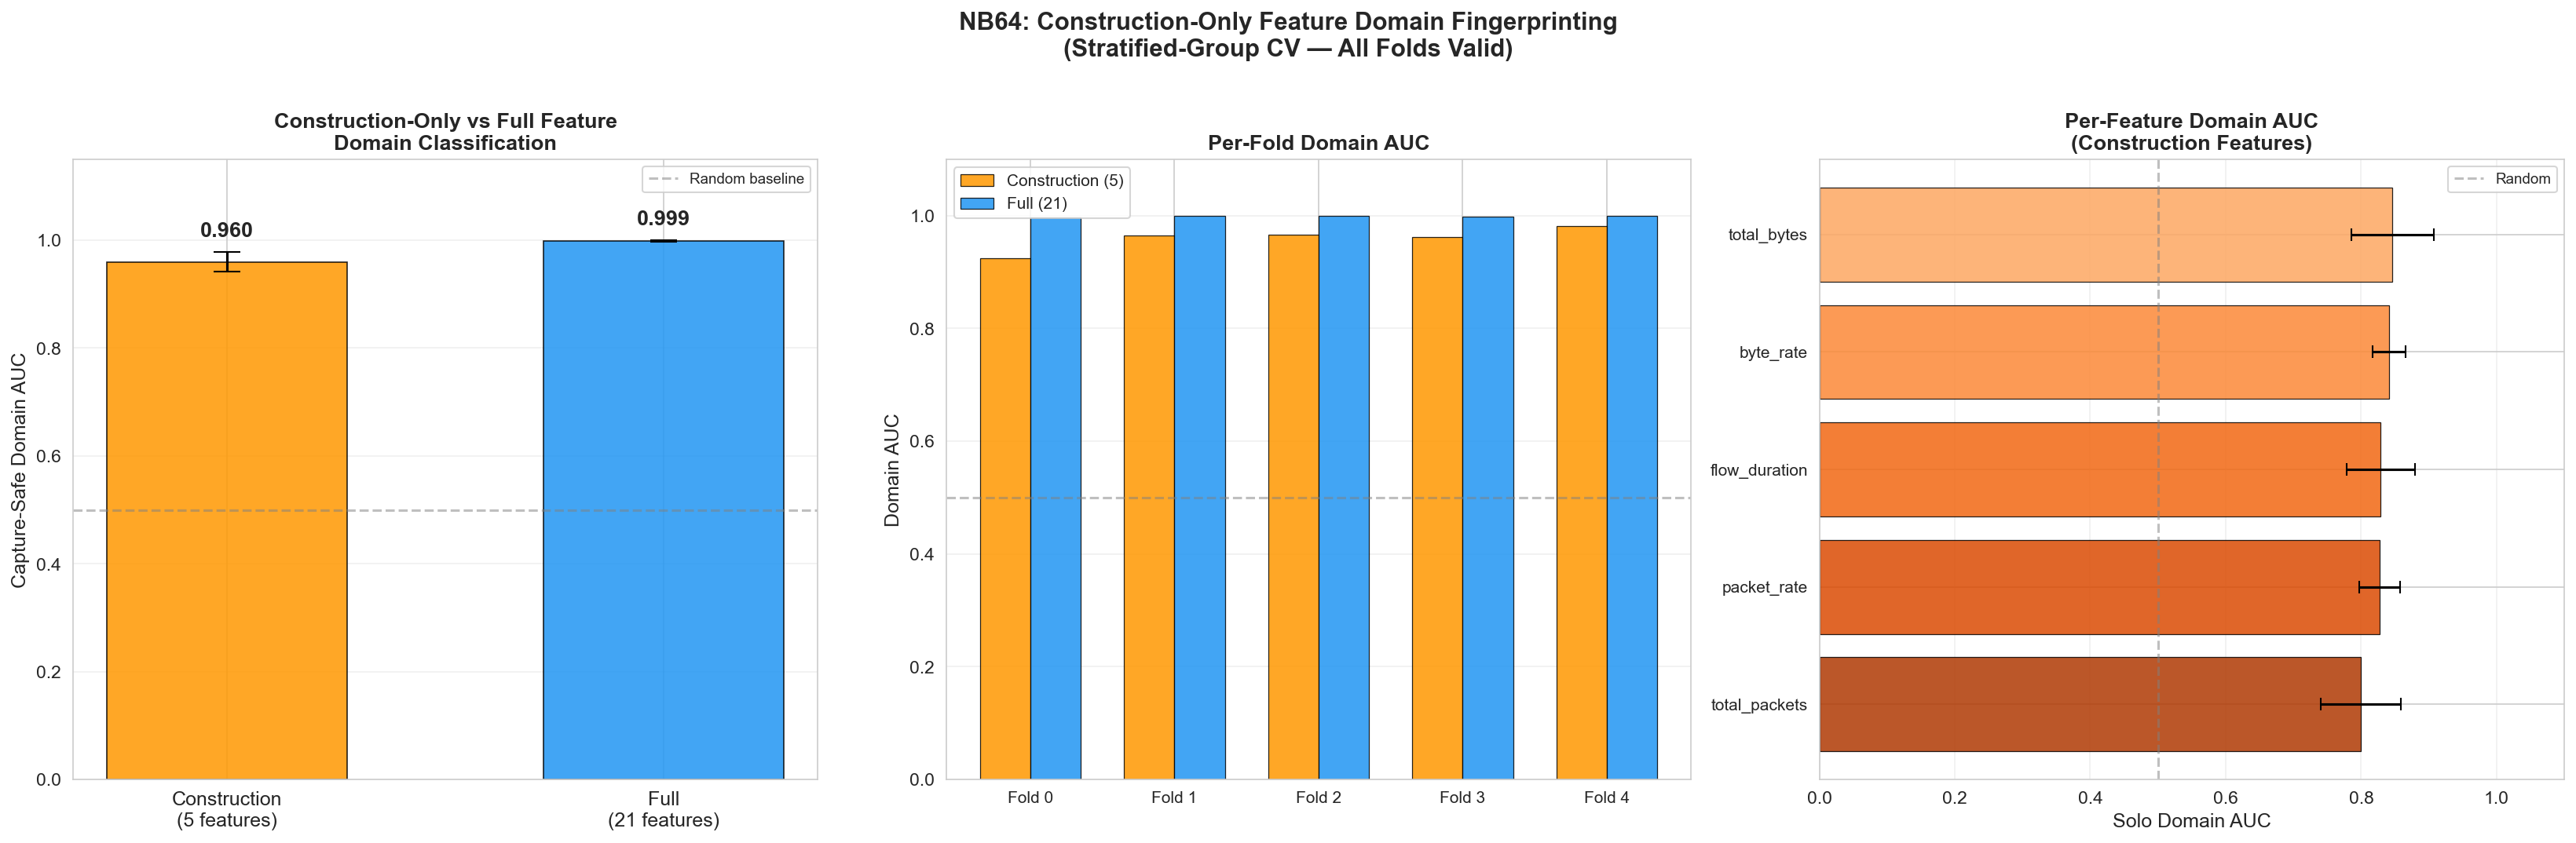


---
### 🖼 Construction Only Domain Auc Plot

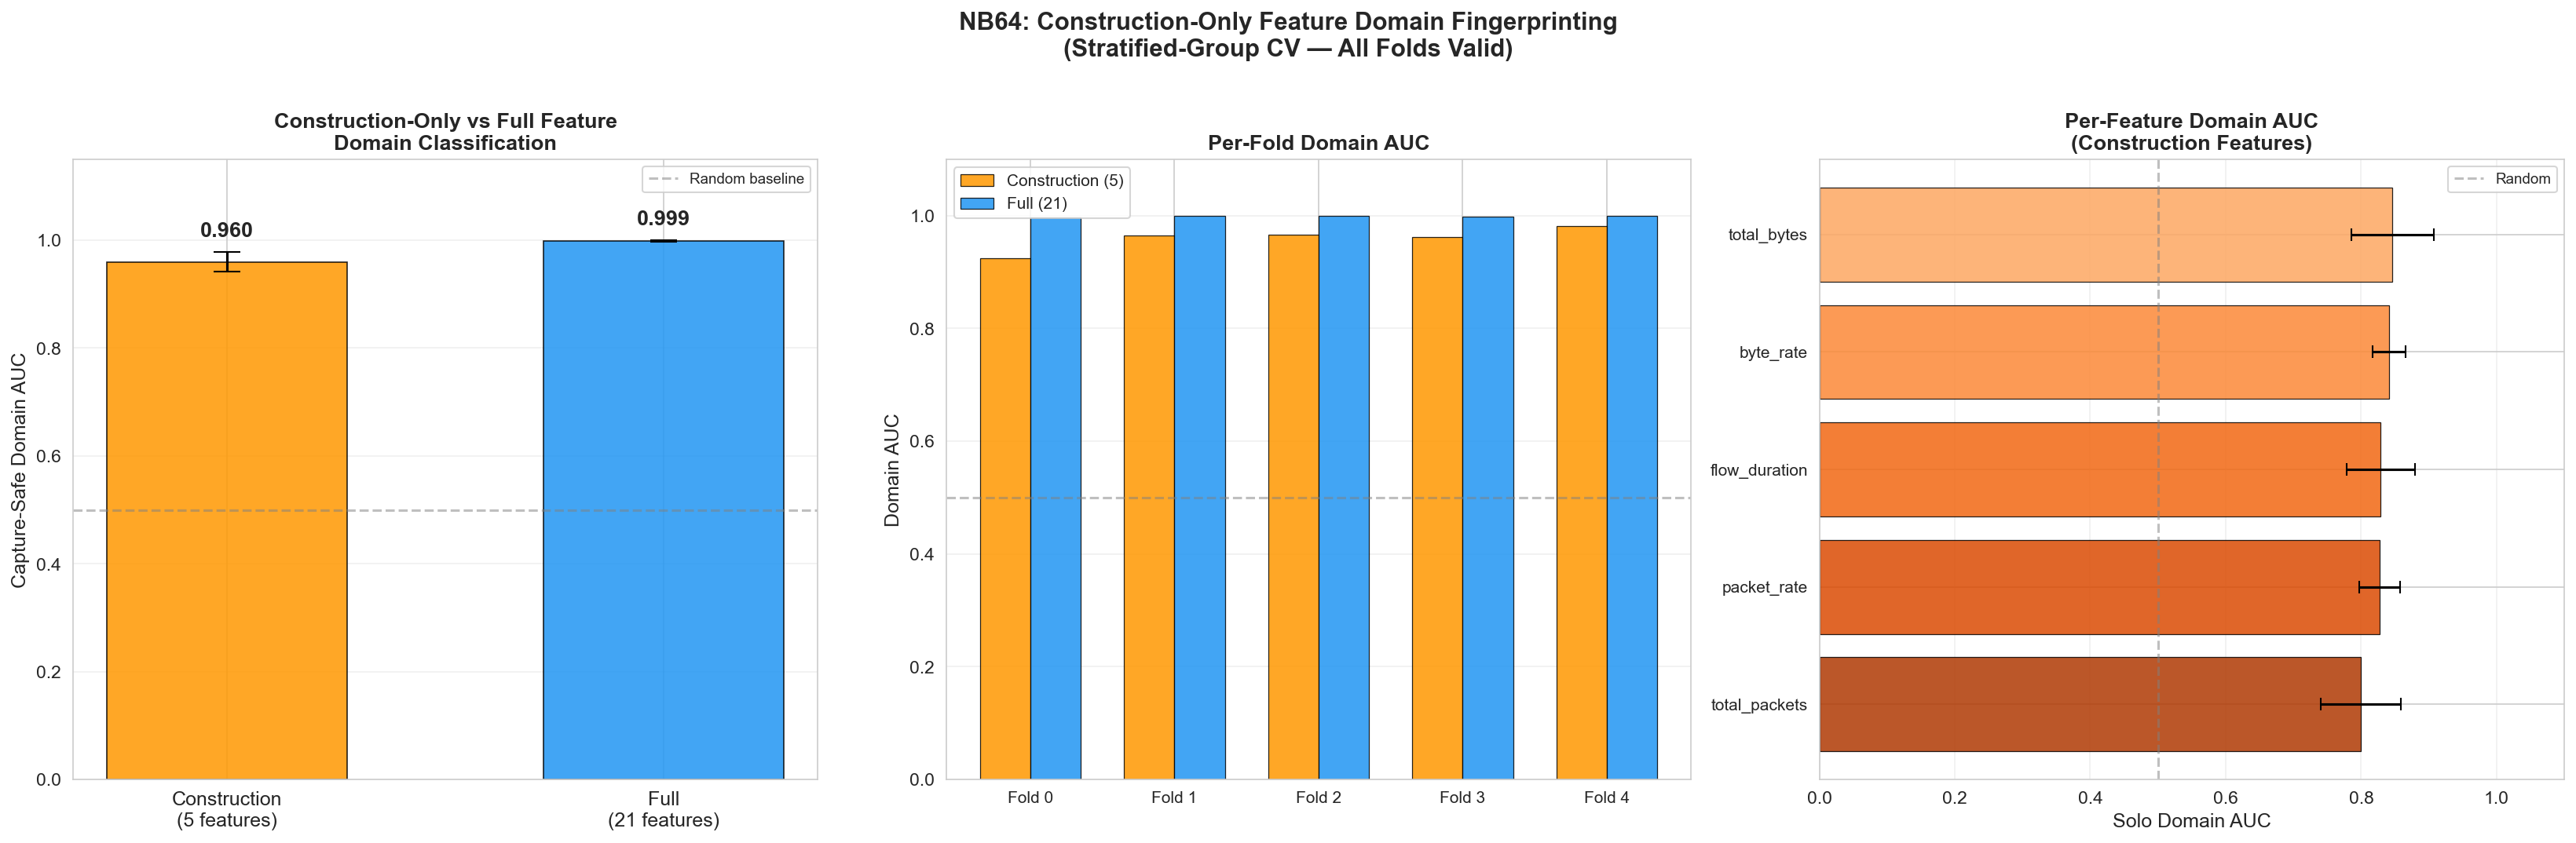


---
# 📋 Result Tables


### Construction Only Domain Auc

,feature_set,n_features,fold,domain_auc,accuracy,n_train,n_test,n_train_captures,n_test_captures,all_classes_test
0,construction_only,5,0,0.9251,0.7598,66708,5904,272,68,True
1,construction_only,5,1,0.9651,0.8982,65242,7370,272,68,True
2,construction_only,5,2,0.9669,0.8437,66417,6195,272,68,True
3,construction_only,5,3,0.9619,0.7820,26006,46606,272,68,True
4,construction_only,5,4,0.9809,0.8889,66075,6537,272,68,True
5,full_21,21,0,0.9964,0.9438,66708,5904,272,68,True
6,full_21,21,1,0.9995,0.9852,65242,7370,272,68,True
7,full_21,21,2,0.9998,0.9926,66417,6195,272,68,True
8,full_21,21,3,0.9979,0.9626,26006,46606,272,68,True
9,full_21,21,4,0.9998,0.9872,66075,6537,272,68,True


### Construction Solo Feature Domain Auc

,feature,domain_auc,std
0,total_bytes,0.8464,0.0613
1,byte_rate,0.8411,0.0248
2,flow_duration,0.8290,0.0508
3,packet_rate,0.8273,0.0302
4,total_packets,0.7995,0.0590



---
### 🏁 Nb64 Summary

```json
{
  "notebook": "NB64",
  "title": "Construction-Only Feature Domain Fingerprinting",
  "correction_note": "Replaced plain GroupKFold with stratified-group K-fold. Captures are assigned to folds round-robin within each dataset, guaranteeing all dataset classes in every fold's train and test sets. No NaN AUC folds. All 5 folds contribute to the mean.",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "construction_features": [
    "flow_duration",
    "total_packets",
    "total_bytes",
    "packet_rate",
    "byte_rate"
  ],
  "n_construction": 5,
  "n_full": 21,
  "construction_domain_auc": 0.9599694506198306,
  "construction_domain_auc_std": 0.018613378643301245,
  "full_domain_auc": 0.9986925952122154,
  "full_domain_auc_std": 0.001357539957503623,
  "ratio": 0.961226162306574,
  "delta": -0.038723144592384795,
  "interpretation": "STRONG: Construction features alone achieve near-perfect domain classification. The flow construction pipeline encodes dataset identity at the most fundamental level.",
  "nan_folds": 0,
  "all_folds_valid": true,
  "solo_feature_ranking": [
    {
      "feature": "total_bytes",
      "domain_auc": 0.8463991129984846,
      "std": 0.06130633411904399
    },
    {
      "feature": "byte_rate",
      "domain_auc": 0.841093006839347,
      "std": 0.0247604044709327
    },
    {
      "feature": "flow_duration",
      "domain_auc": 0.8290360618666298,
      "std": 0.050825013282012894
    },
    {
      "feature": "packet_rate",
      "domain_auc": 0.8272852538649961,
      "std": 0.0302180700166033
    },
    {
      "feature": "total_packets",
      "domain_auc": 0.7994585875035133,
      "std": 0.05899895356114435
    }
  ],
  "cv_config": {
    "method": "StratifiedGroupKFold (custom, capture-level round-robin per dataset)",
    "groups": "capture_id",
    "stratify": "dataset",
    "n_splits": 5,
    "n_estimators": 200,
    "seed": 42
  }
}
```


✅ NB64 gallery complete.


In [10]:
# -- Results Gallery: NB64 -- Display all figures and tables --------
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "thesis_finalization" / "nb64_construction_only_domain_fingerprinting"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB64 Results Gallery \u2014 {len(_pngs)} figures, {len(_csvs)} tables'))

# -- Display all PNG figures --
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {_p.stem.replace("_", " ").title()}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# -- Display all CSV tables --
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {_c.stem.replace("_", " ").title()}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# -- Display JSON verdict if present --
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {_j.stem.replace("_", " ").title()}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB64 gallery complete.')
